![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

Użycie estymatora jądrowego gęstości prawdopodobieństwa (kernel density estimator - KDE)

In [1]:
import scipy.stats as st
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

### Implementacja własnej funkcji
Implementacja własnej funkcji realizującej estymację jądrową nie jest trudna:

In [2]:
def kernel(x): # funkcja jądra
    return 1/(2*np.pi)**0.5*np.exp(-0.5*x**2)

def f(x,sample,h=0.3,K=kernel): # funkcja obliczająca wartość estymatora jądrowego w danym punkcie
    n = len(sample)
    return np.sum(K((x-sample)/h))/(n*h)
    

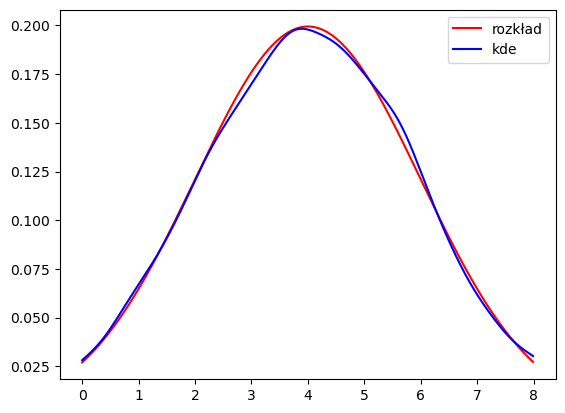

In [3]:
NormalDistribution = st.norm(4,2)
X = NormalDistribution.rvs(10000)

t = np.arange(0,8,0.01)
F = np.zeros(len(t))
for i in range(len(t)):
    F[i] = f(t[i],X)

plt.plot(t,NormalDistribution.pdf(t),"red",t,F,"blue")
plt.legend(["rozkład","kde"])
pass

### Użycie estymatora jądrowego biblioteki [scipy.stats](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html)

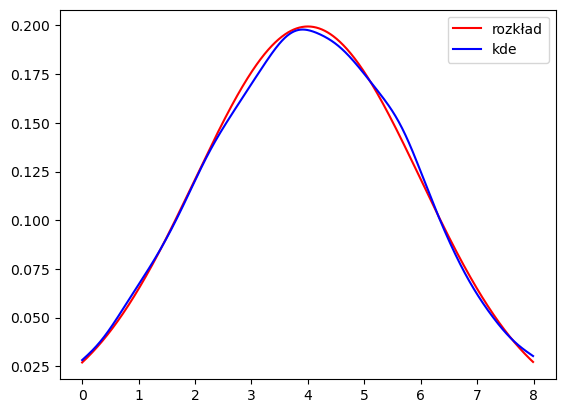

In [4]:
kde_ss_estimator = st.gaussian_kde(X)

plt.plot(t,NormalDistribution.pdf(t),"red",t,kde_ss_estimator(t),"blue")
plt.legend(["rozkład","kde"])
pass

### Użycie estymatora jądrowego biblioteki [statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.nonparametric.kde.KDEUnivariate.html)

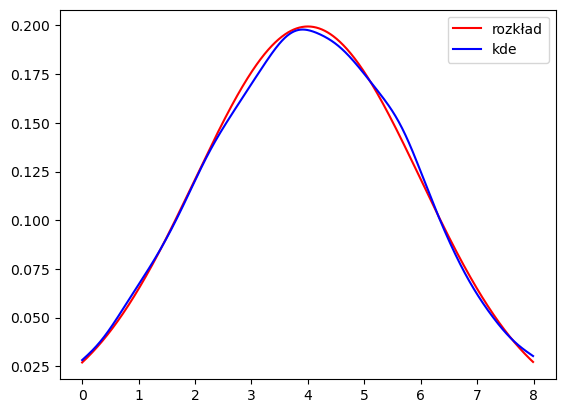

In [5]:
import statsmodels.api as sm

kde_sm_estimator = sm.nonparametric.KDEUnivariate(X)
kde_sm_estimator.fit()

plt.plot(t,NormalDistribution.pdf(t),"red",t,kde_ss_estimator(t),"blue")
plt.legend(["rozkład","kde"])
pass